## This notebook looks into using various python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting whether or not someone will be readmitted into the hospital in 30 days or less than 30 days.


Hospital readmissions significantly increase healthcare costs and often reflect gaps in care continuity. This project analyzes hospital encounter data to uncover patterns linked to 30-day readmissions and deliver data-driven recommendations to improve patient outcomes and reduce avoidable readmissions.

I am going to take following approach in solving this problem:

1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## PROBLEM DEFINITION:
Diabetes (also called Diabetes Mellitus) is a chronic medical condition where your body has trouble regulating blood sugar (glucose) levels.

### 2. Data
https://www.kaggle.com/datasets/brandao/diabetes/data?select=diabetic_data.csv
- 100,000+ patient records
- 50+ features from 130 US hospitals (1999-2008)

### 3. Evaluation
- Primary metric: Recall ≥ 0.80 (minimise missed readmissions)
- Secondary: F1 Score, AUC-ROC
- Baseline: DummyClassifier

### 4. Features
- Patient demographics (age, gender, race)
- Hospital visit data (time in hospital, procedures)
- Medical history (diagnoses, medications, test results)

### 5. Modelling
- Baseline: DummyClassifier
- Logistic Regression, Random Forest, XGBoost, LightGBM
- Hyperparameter tuning with RandomizedSearchCV & GridSearchCV

### 6. Experimentation
- Feature engineering & selection
- Class imbalance handling
- Threshold tuning
- SHAP explainability

**Note**: The task is Can we predict whether a diabetic patient will be readmitted 
to hospital within 30 days based on their medical history?

## Preparing the tools

I am going to use Pandas, Matplotlib, Numpy for data analysis and manipulation.

In [1]:
# Import all the tools i need

# Regular EDA (Exploratory Data Analysis) and plottinh libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

# I want my plot to appear inside the notebook
%matplotlib inline

# Pipeline & Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, recall_score, precision_score, f1_score,roc_curve,
    roc_auc_score, average_precision_score, precision_recall_curve
)

# Feature Importance
from sklearn.inspection import permutation_importance

# Explainability
import shap

In [2]:
# Load the data
df = pd.read_csv('data/diabetic_data.csv', 
                 encoding='latin1', 
                 sep=',', 
                 na_values=['?'],
                low_memory=False)   

# print("Shape:", df.shape)
# print("\nFirst 5 rows:")
df.shape

(101766, 50)

In [3]:
# Save raw copy for EDA
df_raw = df.copy()
print("Raw dataframe saved! ")
print(f"Shape: {df_raw.shape}")

Raw dataframe saved! 
Shape: (101766, 50)


## Data Exploration (Exploratory data analysis or EDA)

The goal is to master this dataset and become the team's go to subject matter expert on the data.

In [4]:
df_raw.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df_raw.sample(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
3940,23265726,5927742,Caucasian,Male,[90-100),NaN,3,5,1,7,...,No,No,No,No,No,No,No,No,No,NO
20951,73397334,69834555,Caucasian,Male,[60-70),NaN,2,1,7,8,...,No,Down,No,No,No,No,No,Ch,Yes,>30
63107,175569234,110877237,Caucasian,Male,[60-70),NaN,2,1,7,4,...,No,Up,No,No,No,No,No,Ch,Yes,>30
65176,181628904,56705337,Caucasian,Female,[80-90),NaN,1,2,7,4,...,No,Down,No,No,No,No,No,Ch,Yes,>30
78561,240145374,91484424,Caucasian,Male,[60-70),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,No,NO


In [6]:
# Consice summary of dataframe
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [7]:
# Column names
df_raw.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [8]:
# Checking for null values
df_raw.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [9]:
# Describe of data
df_raw.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### Target Variable Distribution (Readmission Status)

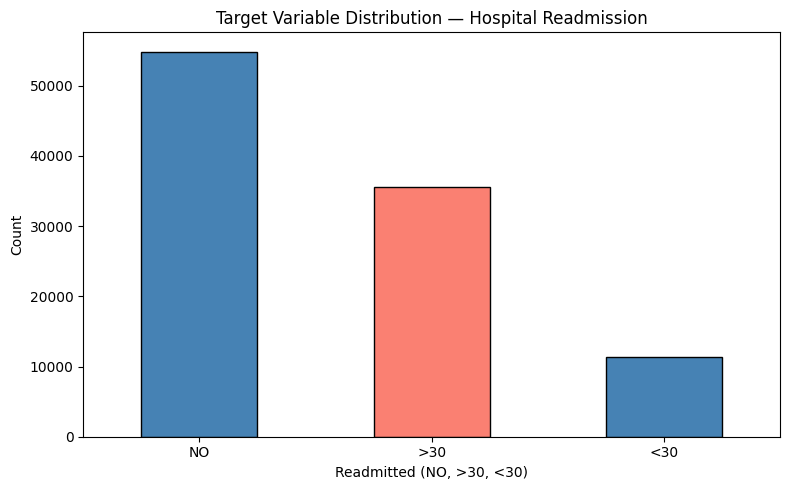

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     53.9
>30    34.9
<30    11.2
Name: proportion, dtype: float64


In [10]:
# Target distribution
plt.figure(figsize=(8, 5))
df_raw["readmitted"].value_counts().plot.bar(
    color=["steelblue", "salmon"],
    edgecolor="black"
)
plt.title("Target Variable Distribution — Hospital Readmission")
plt.xlabel("Readmitted (NO, >30, <30)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df_raw["readmitted"].value_counts())
print(df_raw["readmitted"].value_counts(normalize=True).round(3) * 100)

### Numerical Features Distribution

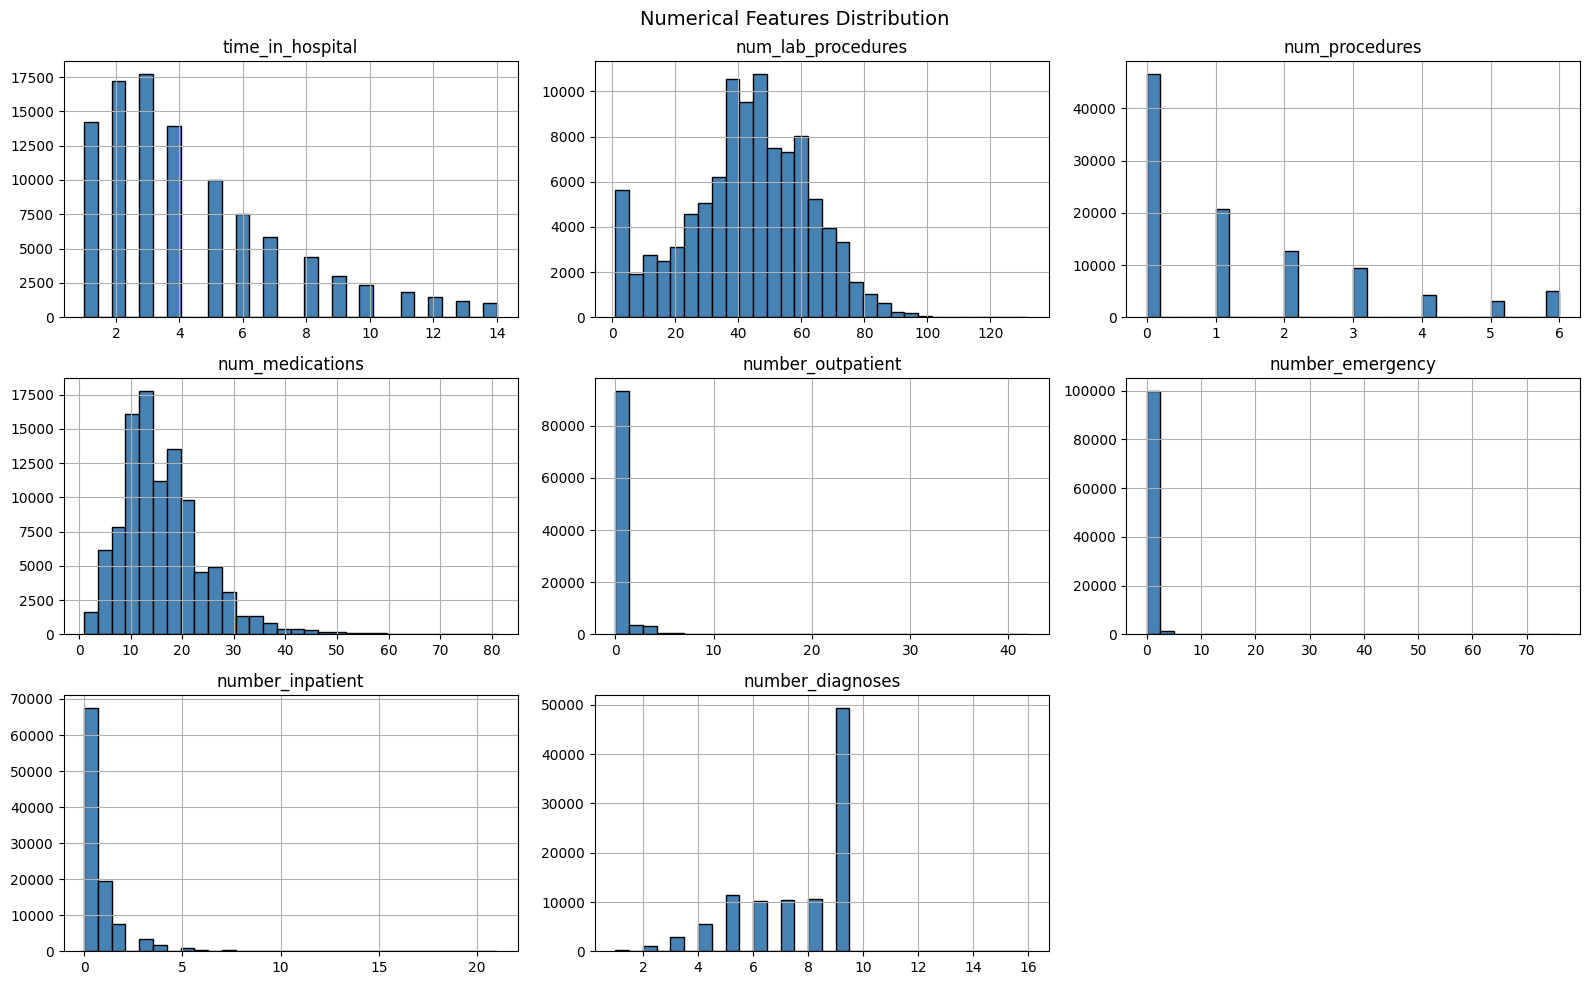

In [11]:
# Numerical features distribution
num_cols = [
    "time_in_hospital", "num_lab_procedures",
    "num_procedures", "num_medications",
    "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses"
]

df_raw[num_cols].hist(
    figsize=(16, 10),
    bins=30,
    color="steelblue",
    edgecolor="black"
)
plt.suptitle("Numerical Features Distribution", fontsize=14)
plt.tight_layout()
plt.show()

### Correlation Matrix

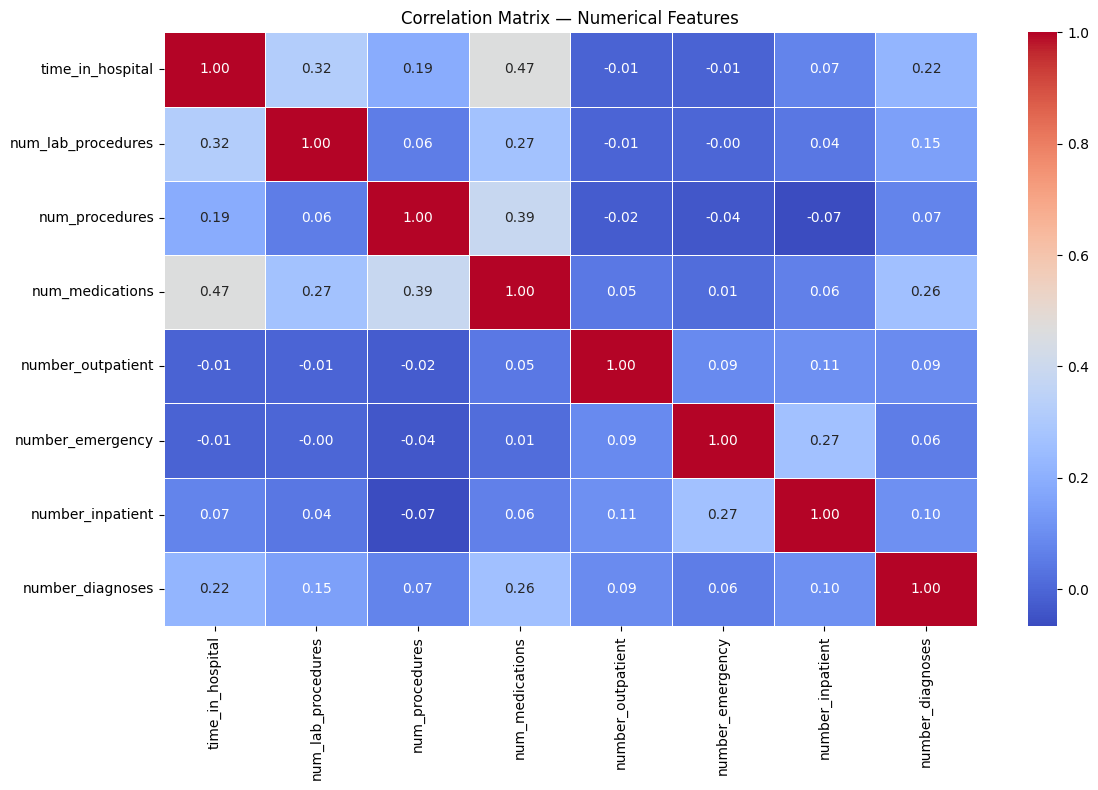

In [12]:
# correlation matrix
plt.figure(figsize=(12, 8))
corr = df_raw[num_cols].corr()
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()

### Age Distribution by Readmission

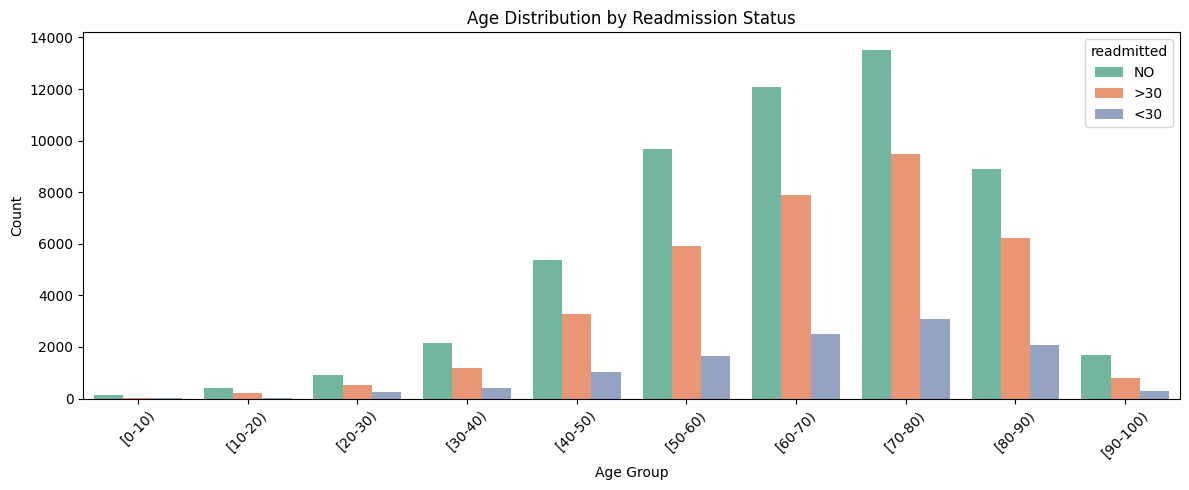

In [13]:
plt.figure(figsize=(12, 5))
sns.countplot(x="age",
              hue="readmitted",
              data=df_raw,
              palette="Set2")
plt.title("Age Distribution by Readmission Status")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 ### Boxplots by Readmission

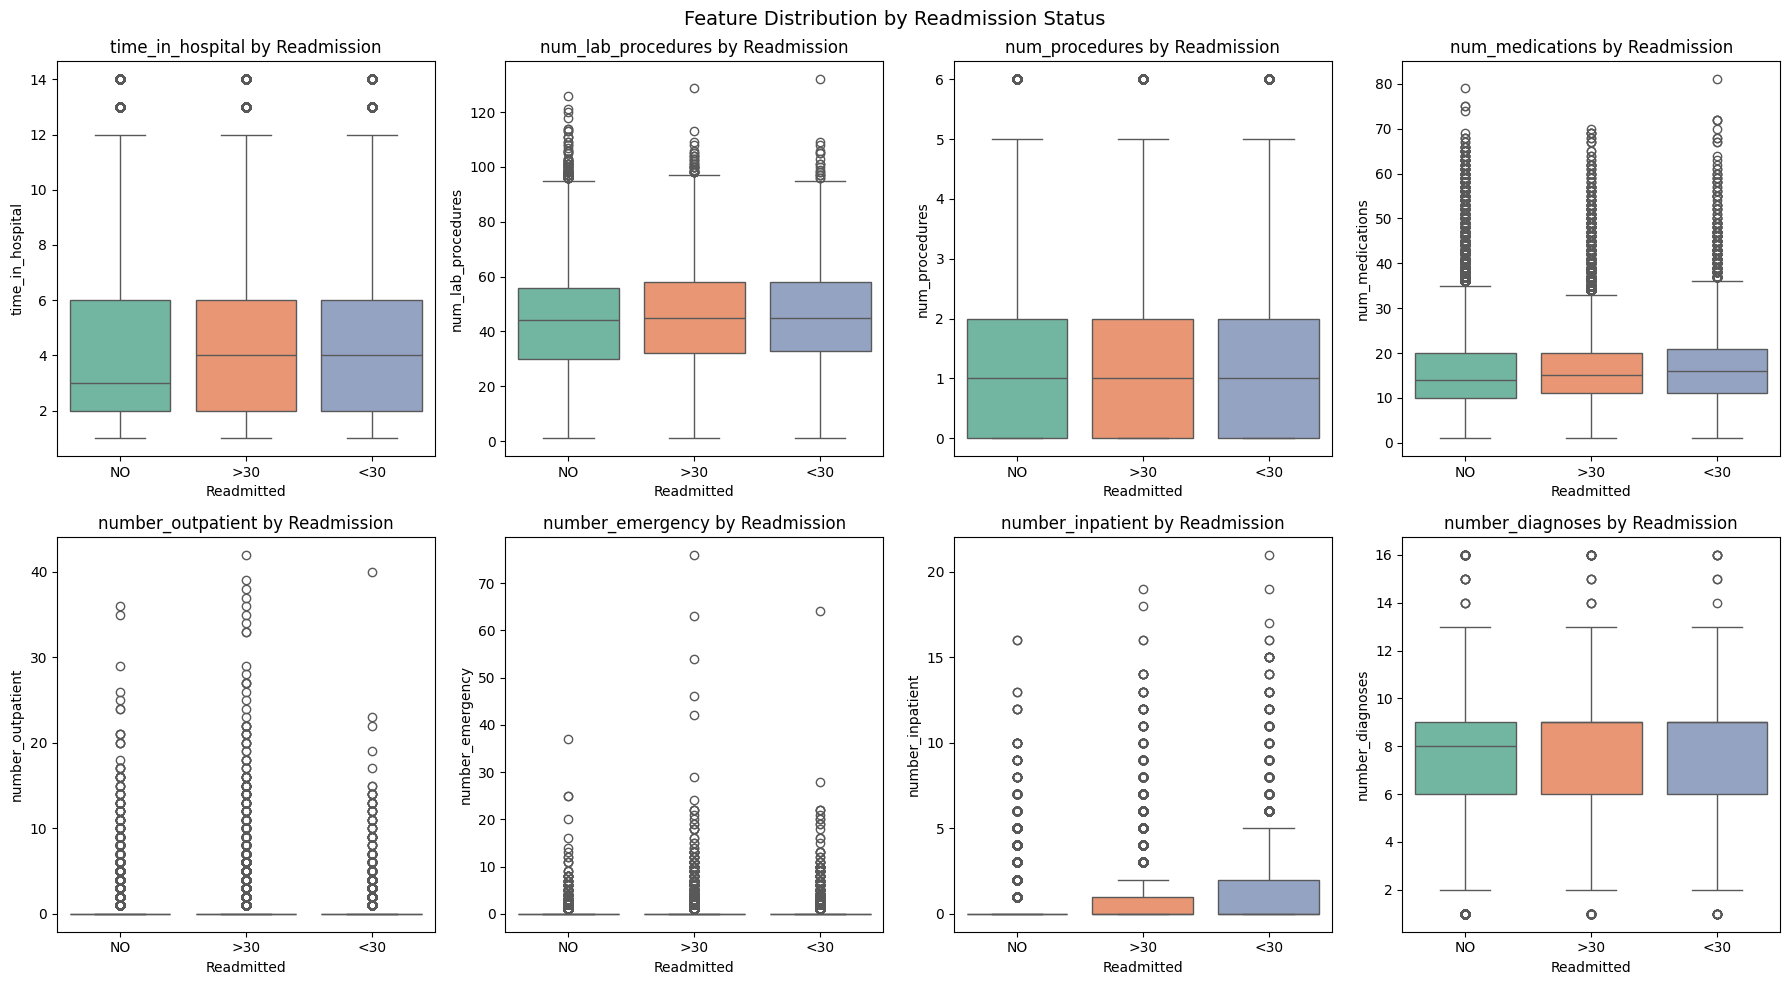

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x="readmitted", y=col,
                data=df_raw,
                hue="readmitted",      
                legend=False,          
                palette="Set2",
                ax=axes[i])
    axes[i].set_title(f"{col} by Readmission")
    axes[i].set_xlabel("Readmitted")

plt.suptitle("Feature Distribution by Readmission Status", fontsize=14)
plt.tight_layout()
plt.show()

### Race Distribution

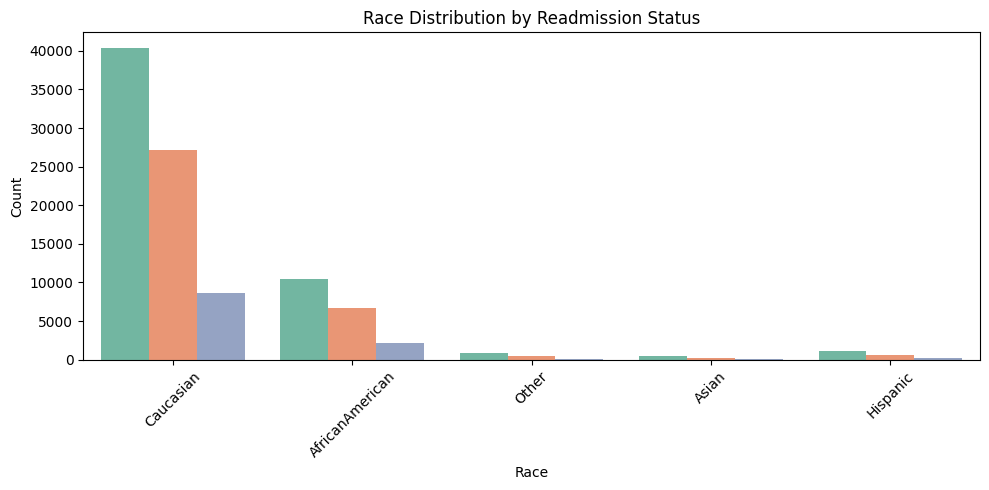

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(x="race",
              hue="readmitted",
              data=df_raw,
              palette="Set2",
              legend=False)          
plt.title("Race Distribution by Readmission Status")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top Medications Used

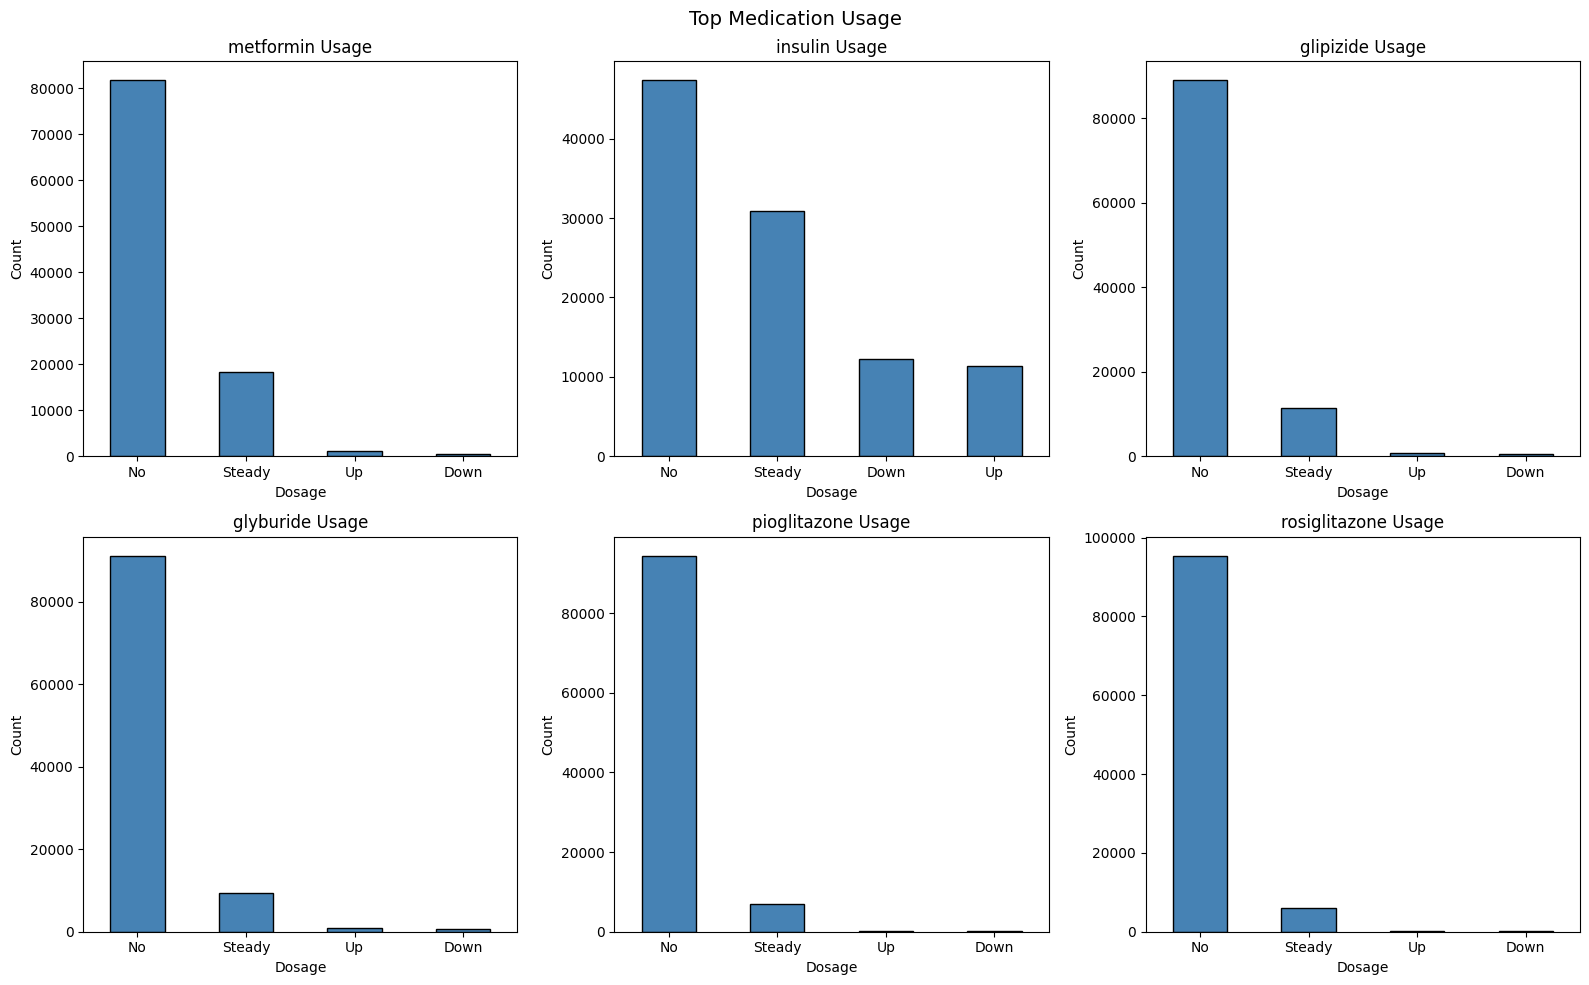

In [16]:
med_cols = [
    "metformin", "insulin", "glipizide",
    "glyburide", "pioglitazone", "rosiglitazone"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(med_cols):
    df_raw[col].value_counts().plot.bar(
        ax=axes[i],
        color="steelblue",
        edgecolor="black"
    )
    axes[i].set_title(f"{col} Usage")
    axes[i].set_xlabel("Dosage")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=0)

plt.suptitle("Top Medication Usage", fontsize=14)
plt.tight_layout()
plt.show()

## Key EDA Insights

- **Class Imbalance:** 88.8% not readmitted vs 11.2% readmitted — serious imbalance
- **Age:** Older patients (60-80) have higher readmission rates
- **Time in hospital:** Readmitted patients tend to stay longer
- **num_medications:** Higher medication count linked to readmission
- **number_inpatient:** Previous inpatient visits strongly linked to readmission
- **Insulin:** Most common medication change among readmitted patients
- **Race:** Caucasian patients dominate the dataset

## Data Preprocessing

In [17]:
# After EDA is done, convert back to df for preprocessing
df = df_raw.copy()
print(f"Back to df! ")
print(f"Shape: {df.shape}")

Back to df! 
Shape: (101766, 50)


Dropping unnecessary columns and rows, replace missing *race* with `mode`

In [18]:
# Drop unnecessary columns
df = df.drop(columns=["encounter_id",
                     "patient_nbr",
                     "weight",
                     "payer_code",
                     "medical_specialty",
                     "A1Cresult",
                     "max_glu_serum"])

# Drop rows where diag_1, diag_2, diag_3 are NaN
df = df.dropna(subset=["diag_1", "diag_2", "diag_3"])

# Replace missing race with mode
df["race"] = df["race"].fillna(df["race"].mode()[0])

# Print
print(f"Dataset shape: {df.shape}")
print(f"\nMissing values remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nNo missing values!") if df.isnull().sum().sum == 0 else None

Dataset shape: (100244, 43)

Missing values remaining:
Series([], dtype: int64)


In [19]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [20]:
# Encode target variable
df["readmitted"] = (df["readmitted"] == "<30").astype(int)

# Check distribution
print("Target distribution:")
print(df["readmitted"].value_counts())
print("/nTarget distribution (%):")
print((df["readmitted"].value_counts(normalize=True) * 100).round(3))

Target distribution:
readmitted
0    88994
1    11250
Name: count, dtype: int64
/nTarget distribution (%):
readmitted
0    88.777
1    11.223
Name: proportion, dtype: float64


In [21]:
# Categorical features

# Age (ordinal)
age_mapping = {
    "[0-10)": 5, "[10-20)": 15, "[20-30)": 25,
    "[30-40)": 35, "[40-50)": 45, "[50-60)": 55,
    "[60-70)": 65, "[70-80)": 75, "[80-90)": 85,
    "[90-100)": 95
}
df["age"] = df["age"].map(age_mapping)

# Binary Columns
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["diabetesMed"] = df["diabetesMed"].map({"Yes": 1, "No": 0})
df["change"] = df["change"].map({"Ch": 1, "No": 0})

# Medications Columns
med_mapping = {"No": 0, "Steady": 1, "Up": 2, "Down": 3}
med_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide",
    "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]
for col in med_cols:
    df[col] = df[col].map(med_mapping)

# Diagnosis codes (group into categories)
def categorize_diag(code):
    try:
        code = str(code)
        if code.startswith("V") or code.startswith("E"):
            return "Other"
        code = float(code)
        if 390 <= code <= 459 or code == 785: return "Circulatory"
        elif 460 <= code <= 519 or code == 786: return "Respiratory"
        elif 520 <= code <= 579 or code == 787: return "Digestive"
        elif code == 250: return "Diabetes"
        elif 800 <= code <= 999: return "Injury"
        elif 710 <= code <= 739: return "Musculoskeletal"
        elif 580 <= code <= 629 or code == 788: return "Genitourinary"
        elif 140 <= code <= 239: return "Neoplasms"
        else: return "Other"
    except:
        return "Other"

df["diag_1"] = df["diag_1"].apply(categorize_diag)
df["diag_2"] = df["diag_2"].apply(categorize_diag)
df["diag_3"] = df["diag_3"].apply(categorize_diag)

# 5 — One-hot encode race, diag_1, diag_2, diag_3 and admission_type_id, discharge_disposition_id, admission_source_id
df = pd.get_dummies(df, columns=[
    "race",
    "diag_1", "diag_2", "diag_3",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
], drop_first=True)

print(f"Shape after encoding: {df.shape}")
print(f"\nData types:")
print(df.dtypes.value_counts())

Shape after encoding: (100244, 112)

Data types:
bool       76
int64      35
float64     1
Name: count, dtype: int64


In [22]:
# Convert bool columns to int
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Data types after fix:")
print(df.dtypes.value_counts())

Data types after fix:
int64      111
float64      1
Name: count, dtype: int64


In [23]:
# Handling Class Imbalance in the Target Variable

# Calculate scale_pos_weight for XGBoost
negative = (df["readmitted"] ==0).sum()
positive = (df["readmitted"] ==1).sum()
scale_pos_weight = negative / positive

print(f"Negative class (0): {negative}")
print(f"Positive class (1): {positive}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Negative class (0): 88994
Positive class (1): 11250
scale_pos_weight: 7.91


In [24]:
# Train/Test Split

# Split features and target
X = df.drop(columns=["readmitted"])
y = df["readmitted"]

In [25]:
# Visusalize X
X

,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,admission_source_id_8,admission_source_id_9,admission_source_id_10,admission_source_id_11,admission_source_id_13,admission_source_id_14,admission_source_id_17,admission_source_id_20,admission_source_id_22,admission_source_id_25
1,0.0,15,3,59,0,18,0,0,0,9,...,0,0,0,0,0,0,0,0,0,0
2,0.0,25,2,11,5,13,2,0,1,6,...,0,0,0,0,0,0,0,0,0,0
3,1.0,35,2,44,1,16,0,0,0,7,...,0,0,0,0,0,0,0,0,0,0
4,1.0,45,1,51,0,8,0,0,0,5,...,0,0,0,0,0,0,0,0,0,0
5,1.0,55,3,31,6,16,0,0,0,9,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,1.0,75,3,51,0,16,0,0,0,9,...,0,0,0,0,0,0,0,0,0,0
101762,0.0,85,5,33,3,18,0,0,1,9,...,0,0,0,0,0,0,0,0,0,0
101763,1.0,75,1,53,0,9,1,0,0,13,...,0,0,0,0,0,0,0,0,0,0
101764,0.0,85,10,45,2,21,0,0,1,9,...,0,0,0,0,0,0,0,0,0,0


In [26]:
# Visualize y
y

1         0
2         0
3         0
4         0
5         0
         ..
101761    0
101762    0
101763    0
101764    0
101765    0
Name: readmitted, Length: 100244, dtype: int64

In [27]:
# Split the data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X,
                                                      y,
                                                      test_size=0.2,
                                                      random_state=42,
                                                      stratify=y)

# Convert to DataFrame to preserve feature names
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"X_train type:  {type(X_train)}")
print(f"X_test type:   {type(X_test)}")

# Verify stratification
print("\nTrain distribution:")
print(pd.Series(y_train).value_counts(normalize=True).round(3) * 100)
print("\nTest distribution:")
print(pd.Series(y_test).value_counts(normalize=True).round(3) * 100)
print("\nFeature names preserved!")

X_train shape: (80195, 111)
X_test shape:  (20049, 111)
X_train type:  <class 'pandas.DataFrame'>
X_test type:   <class 'pandas.DataFrame'>

Train distribution:
readmitted
0    88.8
1    11.2
Name: proportion, dtype: float64

Test distribution:
readmitted
0    88.8
1    11.2
Name: proportion, dtype: float64

Feature names preserved!


In [28]:
X_train

,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,admission_source_id_8,admission_source_id_9,admission_source_id_10,admission_source_id_11,admission_source_id_13,admission_source_id_14,admission_source_id_17,admission_source_id_20,admission_source_id_22,admission_source_id_25
18541,0.0,65,2,70,0,14,0,0,3,8,...,0,0,0,0,0,0,0,0,0,0
1441,0.0,85,4,61,0,9,0,0,0,5,...,0,0,0,0,0,0,0,0,0,0
8238,0.0,65,2,70,4,13,0,0,4,8,...,0,0,0,0,0,0,0,0,0,0
93606,0.0,85,9,77,3,37,0,0,0,5,...,0,0,0,0,0,0,0,0,0,0
82735,0.0,65,4,42,0,12,0,0,0,5,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37712,0.0,65,4,24,1,21,0,0,0,7,...,0,0,0,0,0,0,0,0,0,0
25967,1.0,45,2,31,2,7,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
30071,0.0,65,3,10,0,16,0,0,0,8,...,0,0,0,0,0,0,1,0,0,0
65615,0.0,65,3,48,0,15,0,0,0,9,...,0,0,0,0,0,0,0,0,0,0


In [29]:
y_train

18541    0
1441     0
8238     0
93606    0
82735    0
        ..
37712    0
25967    0
30071    1
65615    1
49456    0
Name: readmitted, Length: 80195, dtype: int64

### Modelling

After splitting the data into training and test sets, we will now train and evaluate several machine learning models.

I will evaluate the following **five machine learning models** for hospital readmission prediction:

1. DummyClassifier          
2. Logistic Regression      
3. Random Forest            
4. XGBoost                  
5. LightGBM                 

In [30]:
# Put all the models in dictionary

# Import SimpleImputer to handle NaN values in the data
from sklearn.impute import SimpleImputer
models = {
    "Dummy Classifier": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", XGBClassifier(
            random_state=42,
            scale_pos_weight=7.91
        ))
    ]),

    "LightGBM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LGBMClassifier(
            random_state=42,
            class_weight="balanced",
            verbose=-1
        ))
    ])
}

# Create a function to fit and score the models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fit and evaluate multiple models
    """
    results = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        results[name] = acc
        print(f"{name:<25} Accuracy: {acc*100:.2f}% | Recall: {recall:.3f} | F1: {f1:.3f}")
    return results                            

In [31]:
model_scores = fit_and_score(models=models,
                            X_train=X_train,
                            X_test=X_test,
                            y_train=y_train,
                            y_test=y_test)
model_scores

Dummy Classifier          Accuracy: 88.78% | Recall: 0.000 | F1: 0.000
Logistic Regression       Accuracy: 67.03% | Recall: 0.546 | F1: 0.271
Random Forest             Accuracy: 88.41% | Recall: 0.062 | F1: 0.107
XGBoost                   Accuracy: 68.73% | Recall: 0.539 | F1: 0.279
LightGBM                  Accuracy: 66.85% | Recall: 0.583 | F1: 0.283


{'Dummy Classifier': 0.8877749513691456,
 'Logistic Regression': 0.6703077460222455,
 'Random Forest': 0.8841338720135667,
 'XGBoost': 0.6872661978153524,
 'LightGBM': 0.6684622674447603}

## Model Comparison

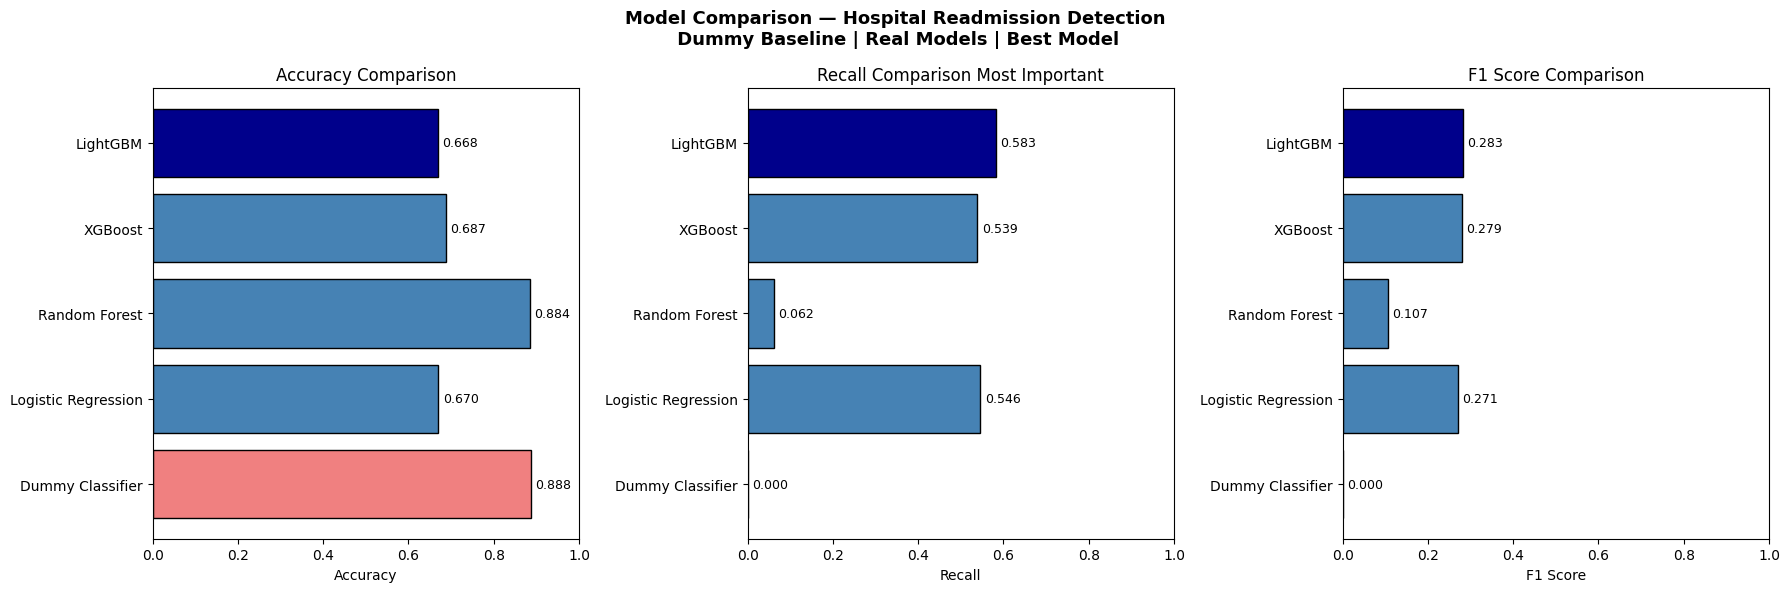

In [32]:
# Model comparison — Recall focused
model_names = ["Dummy Classifier", "Logistic Regression", 
               "Random Forest", "XGBoost", "LightGBM"]

accuracy = [0.8878, 0.6703, 0.8841, 0.6873, 0.6685]
recall   = [0.000,  0.546,  0.062,  0.539,  0.583]
f1       = [0.000,  0.271,  0.107,  0.279,  0.283]

# Colors — highlight best model
colors = ["lightcoral" if name == "Dummy Classifier"
          else "darkblue" if name == "LightGBM"
          else "steelblue" for name in model_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Accuracy
axes[0].barh(model_names, accuracy, color=colors, edgecolor="black")
axes[0].set_title("Accuracy Comparison")
axes[0].set_xlabel("Accuracy")
axes[0].set_xlim([0, 1])
for j, v in enumerate(accuracy):
    axes[0].text(v + 0.01, j, f"{v:.3f}", va="center", fontsize=9)

# Recall
axes[1].barh(model_names, recall, color=colors, edgecolor="black")
axes[1].set_title("Recall Comparison Most Important")
axes[1].set_xlabel("Recall")
axes[1].set_xlim([0, 1])
for j, v in enumerate(recall):
    axes[1].text(v + 0.01, j, f"{v:.3f}", va="center", fontsize=9)

# F1
axes[2].barh(model_names, f1, color=colors, edgecolor="black")
axes[2].set_title("F1 Score Comparison")
axes[2].set_xlabel("F1 Score")
axes[2].set_xlim([0, 1])
for j, v in enumerate(f1):
    axes[2].text(v + 0.01, j, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("Model Comparison — Hospital Readmission Detection\n"
             " Dummy Baseline | Real Models | Best Model",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Model Evaluation

Now that i have baseline results, accuracy alone is not sufficient 
to evaluate model performance — especially on an imbalanced dataset 
where 88.8% of patients were not readmitted.

I will evaluate my models using the following metrics:

1. **Confusion Matrix** — See true/false positives and negatives
2. **Classification Report** — Precision, Recall, F1 per class
3. **ROC Curve + AUC** — Overall discrimination ability
4. **Cross Validation** — Confirm consistency across folds
5. **Feature Importance** — Understand what drives predictions
6. **Hyperparameter Tuning** — Optimise best models

### Why Recall is my Primary Metric
In hospital readmission prediction:
- **False Negative** = missed readmission = patient suffers 
- **False Positive** = unnecessary follow up = less costly 

Therefore i optimise for **Recall** — catching as many 
readmissions as possible — not just overall accuracy.

## Confusion Matrix for my best three models, whuch are:

1. Logistic Regression.
2. XGBoost
3. LightGBM

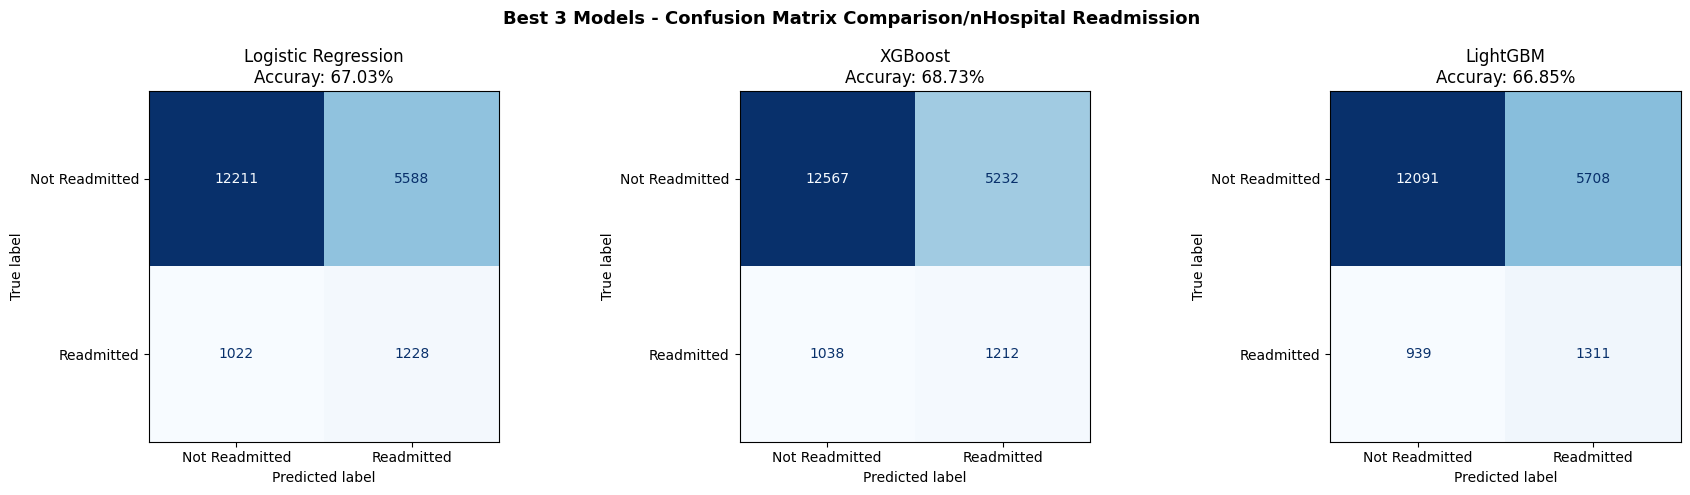

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

best_models = ["Logistic Regression", "XGBoost", "LightGBM"]

for i, name in enumerate(best_models):
    y_pred = models[name].predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not Readmitted", "Readmitted"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(f"{name}\nAccuray: {acc*100:.2F}%")

plt.suptitle("Best 3 Models - Confusion Matrix Comparison/nHospital Readmission",
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [34]:
print(f"{'='*60}")
for name in best_models:
    y_pred = models[name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}")
    print(f"  True Negatives  (Not readmitted correctly): {tn}")
    print(f"  False Positives (Not readmitted wrongly flagged): {fp}")
    print(f"  False Negatives (Readmission missed!): {fn}")
    print(f"  True Positives  (Readmission correctly caught): {tp}")
    print(f"  Readmissions caught: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")
print(f"{'='*60}")


Logistic Regression
  True Negatives  (Not readmitted correctly): 12211
  False Positives (Not readmitted wrongly flagged): 5588
  False Negatives (Readmission missed!): 1022
  True Positives  (Readmission correctly caught): 1228
  Readmissions caught: 1228/2250 (54.6%)

XGBoost
  True Negatives  (Not readmitted correctly): 12567
  False Positives (Not readmitted wrongly flagged): 5232
  False Negatives (Readmission missed!): 1038
  True Positives  (Readmission correctly caught): 1212
  Readmissions caught: 1212/2250 (53.9%)

LightGBM
  True Negatives  (Not readmitted correctly): 12091
  False Positives (Not readmitted wrongly flagged): 5708
  False Negatives (Readmission missed!): 939
  True Positives  (Readmission correctly caught): 1311
  Readmissions caught: 1311/2250 (58.3%)


## Classification Report

In [35]:
best_models = ["Logistic Regression", "XGBoost", "LightGBM"]

for name in best_models:
    y_pred = models[name].predict(X_test)
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["Not Readmitted", "Readmitted"]))


 Logistic Regression
                precision    recall  f1-score   support

Not Readmitted       0.92      0.69      0.79     17799
    Readmitted       0.18      0.55      0.27      2250

      accuracy                           0.67     20049
     macro avg       0.55      0.62      0.53     20049
  weighted avg       0.84      0.67      0.73     20049


 XGBoost
                precision    recall  f1-score   support

Not Readmitted       0.92      0.71      0.80     17799
    Readmitted       0.19      0.54      0.28      2250

      accuracy                           0.69     20049
     macro avg       0.56      0.62      0.54     20049
  weighted avg       0.84      0.69      0.74     20049


 LightGBM
                precision    recall  f1-score   support

Not Readmitted       0.93      0.68      0.78     17799
    Readmitted       0.19      0.58      0.28      2250

      accuracy                           0.67     20049
     macro avg       0.56      0.63      0.53     200

## ROC Curve + AUC

<function matplotlib.pyplot.show(close=None, block=None)>

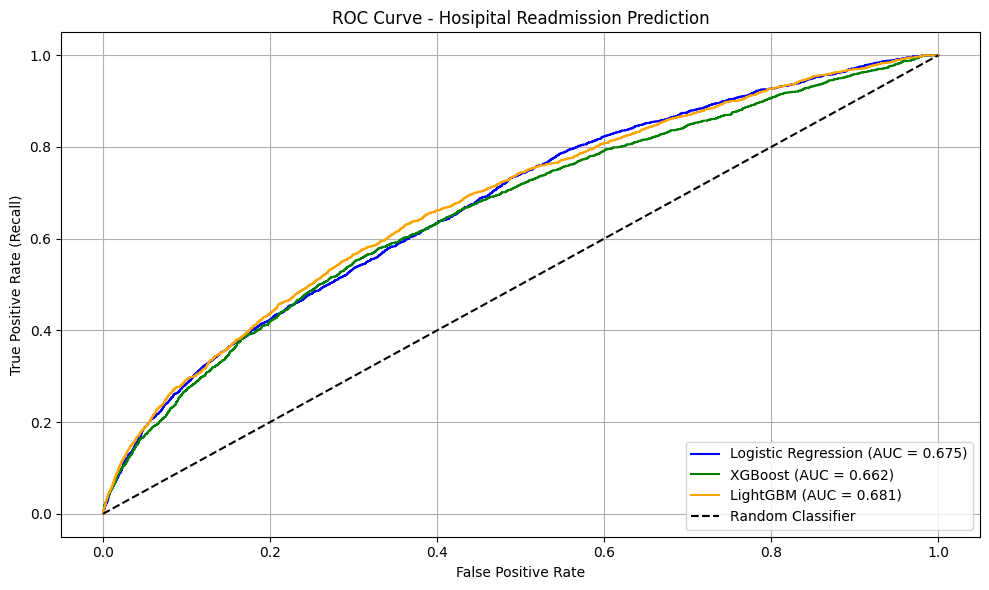

In [36]:
plt.figure(figsize=(10, 6))

best_models = ["Logistic Regression", "XGBoost", "LightGBM"]
colors = ["blue", "green", "orange"]

for name, color in zip(best_models, colors):
    y_pred_proba = models[name].predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC = {roc_auc:.3f})")

# Random Classifier line    
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.title("ROC Curve - Hosipital Readmission Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show

## Cross Validation

In [37]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models = ["Logistic Regression", "XGBoost", "LightGBM"]

print("Cross Validation Results (on X_train only):")
print("="*60)

for name in best_models:
    scores = cross_val_score(
        models[name],
        X_train, y_train,    
        cv=skf,              
        scoring="recall"     
    )
    print(f"\n{name}")
    print(f"  CV Scores:  {scores.round(3)}")
    print(f"  Mean:       {scores.mean():.3f}")
    print(f"  Std Dev:    {scores.std():.3f}")

Cross Validation Results (on X_train only):

Logistic Regression
  CV Scores:  [0.541 0.574 0.544 0.544 0.558]
  Mean:       0.552
  Std Dev:    0.013

XGBoost
  CV Scores:  [0.497 0.48  0.501 0.483 0.498]
  Mean:       0.492
  Std Dev:    0.009

LightGBM
  CV Scores:  [0.554 0.567 0.553 0.538 0.566]
  Mean:       0.556
  Std Dev:    0.011


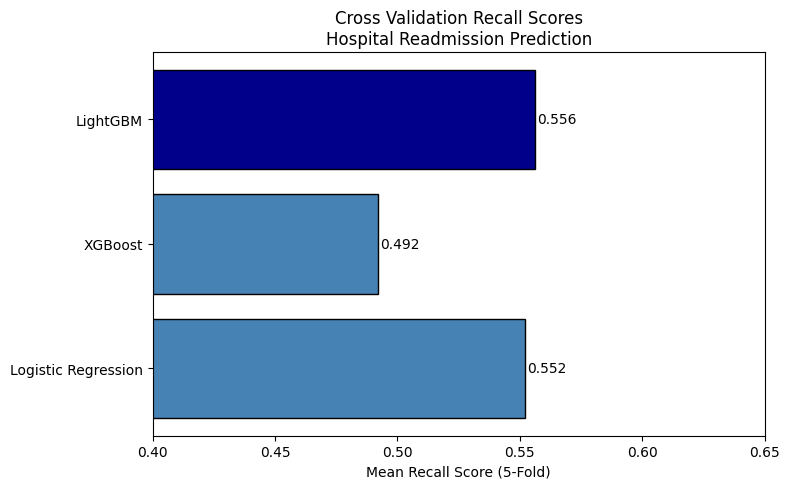

In [38]:
cv_means = {
    "Logistic Regression": 0.552,
    "XGBoost": 0.492,
    "LightGBM": 0.556
}

plt.figure(figsize=(8, 5))
plt.barh(list(cv_means.keys()),
         list(cv_means.values()),
         color=["steelblue", "steelblue", "darkblue"],
         edgecolor="black")
plt.title("Cross Validation Recall Scores\nHospital Readmission Prediction")
plt.xlabel("Mean Recall Score (5-Fold)")
plt.xlim([0.40, 0.65])
for i, v in enumerate(cv_means.values()):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

Hyperparameter tuning for **LightGBM**. I Will be using *RandomizedSearchCV*.

In [39]:
# Define parameter Grid
param_grid_lgbm = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [3, 4, 5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "model__num_leaves": [20, 31, 50, 70, 100],
    "model__min_child_samples": [10, 20, 30, 50],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [0, 0.1, 0.5, 1.0]
}
print("Parameter grid defined!")

Parameter grid defined!


In [40]:
# RandonmizedSearch for LighGBM
rs_lgbm = RandomizedSearchCV(
    estimator=models["LightGBM"],
    param_distributions=param_grid_lgbm,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="recall",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs_lgbm.fit(X_train, y_train)

print(f"\nBest Parameters: {rs_lgbm.best_params_}")
print(f"Best Recall Score: {rs_lgbm.best_score_:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'model__subsample': 0.6, 'model__reg_lambda': 0, 'model__reg_alpha': 0.1, 'model__num_leaves': 50, 'model__n_estimators': 100, 'model__min_child_samples': 30, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}
Best Recall Score: 0.604


In [41]:
# Evaluate tuned model
best_lgbm = rs_lgbm.best_estimator_
y_pred_tuned = best_lgbm.predict(X_test)

print("Tuned LightGBM Results:")
print("="*50)
print(classification_report(y_test, y_pred_tuned,
                           target_names=["Not Readmitted",
                                        "Readmitted"]))

Tuned LightGBM Results:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.62      0.74     17799
    Readmitted       0.17      0.61      0.26      2250

      accuracy                           0.62     20049
     macro avg       0.55      0.62      0.50     20049
  weighted avg       0.84      0.62      0.69     20049



## Compare before and after LightGBM results

In [42]:
# Before tuning
y_pred_default = models["LightGBM"].predict(X_test)
default_recall = recall_score(y_test, y_pred_default)
default_f1 = f1_score(y_test, y_pred_default)
default_auc = roc_auc_score(y_test,
              models["LightGBM"].predict_proba(X_test)[:, 1])

# After tuning
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test,
            best_lgbm.predict_proba(X_test)[:, 1])

print(f"{'Metric':<15} {'Default':>10} {'Tuned':>10} {'Change':>10}")
print("="*45)
print(f"{'Recall':<15} {default_recall:>10.3f} {tuned_recall:>10.3f} {tuned_recall-default_recall:>+10.3f}")
print(f"{'F1 Score':<15} {default_f1:>10.3f} {tuned_f1:>10.3f} {tuned_f1-default_f1:>+10.3f}")
print(f"{'AUC':<15} {default_auc:>10.3f} {tuned_auc:>10.3f} {tuned_auc-default_auc:>+10.3f}")

Metric             Default      Tuned     Change
Recall               0.583      0.610     +0.027
F1 Score             0.283      0.265     -0.018
AUC                  0.681      0.666     -0.014


Hyperparameter tuning for XGBoost. I Will be using RandomizedSearchCV.

In [43]:
# Define parameter grid
param_grid_xgb = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [3, 4, 5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 2, 3, 4, 5],
    "model__reg_alpha": [0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [0, 0.1, 0.5, 1.0],
    "model__gamma": [0, 0.1, 0.2, 0.3]
}
print("XGBoost parameter grid defined!")

XGBoost parameter grid defined!


In [44]:
# Randomizedsearch for XGBoost
rs_xgb = RandomizedSearchCV(
    estimator=models["XGBoost"],
    param_distributions=param_grid_xgb,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="recall",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs_xgb.fit(X_train, y_train)

print(f"\nBest Parameters: {rs_xgb.best_params_}")
print(f"Best Recall Score: {rs_xgb.best_score_:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'model__subsample': 0.7, 'model__reg_lambda': 0, 'model__reg_alpha': 0, 'model__n_estimators': 100, 'model__min_child_weight': 4, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 0.9}
Best Recall Score: 0.591


In [45]:
# Evaluaye tuned model
best_xgb = rs_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)

print("Tuned XGBoost Results:")
print("="*50)
print(classification_report(y_test, y_pred_xgb_tuned,
                             target_names=["Not Readmitted",
                                           "Readmitted"]))

Tuned XGBoost Results:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.64      0.76     17799
    Readmitted       0.18      0.60      0.27      2250

      accuracy                           0.64     20049
     macro avg       0.55      0.62      0.52     20049
  weighted avg       0.84      0.64      0.70     20049



## Compare LightGBM and XGBoost Models

In [46]:
# Default XGBoost
y_pred_xgb_default = models["XGBoost"].predict(X_test)

# Tuned LightGBM
y_pred_lgbm_tuned = best_lgbm.predict(X_test)

print(f"{'Model':<30} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("="*55)

# Default models
for name in ["LightGBM", "XGBoost"]:
    y_pred = models[name].predict(X_test)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, models[name].predict_proba(X_test)[:, 1])
    print(f"{name + ' (default)':<30} {recall:>8.3f} {f1:>8.3f} {auc:>8.3f}")

# Tuned models
for name, model, y_pred in [
    ("LightGBM (tuned)", best_lgbm, y_pred_lgbm_tuned),
    ("XGBoost (tuned)", best_xgb, y_pred_xgb_tuned)
]:
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"{name:<30} {recall:>8.3f} {f1:>8.3f} {auc:>8.3f}")

Model                            Recall       F1      AUC
LightGBM (default)                0.583    0.283    0.681
XGBoost (default)                 0.539    0.279    0.662
LightGBM (tuned)                  0.610    0.265    0.666
XGBoost (tuned)                   0.604    0.272    0.673


I tuned the top 2 models using **RandomizedSearchCV** (50 iterations, 
StratifiedKFold n_splits=5) optimising for **Recall** — our primary 
metric for this medical project.

### Final Model — LightGBM (tuned) 
Selected based on highest Recall **(0.610)** — catching the most 
readmissions is the priority in hospital readmission detection.

> Note: F1 and AUC dropped slightly after tuning — expected trade-off 
> when optimising for Recall. Threshold tuning will address this next.

## Threshold Tuning for LightGBM

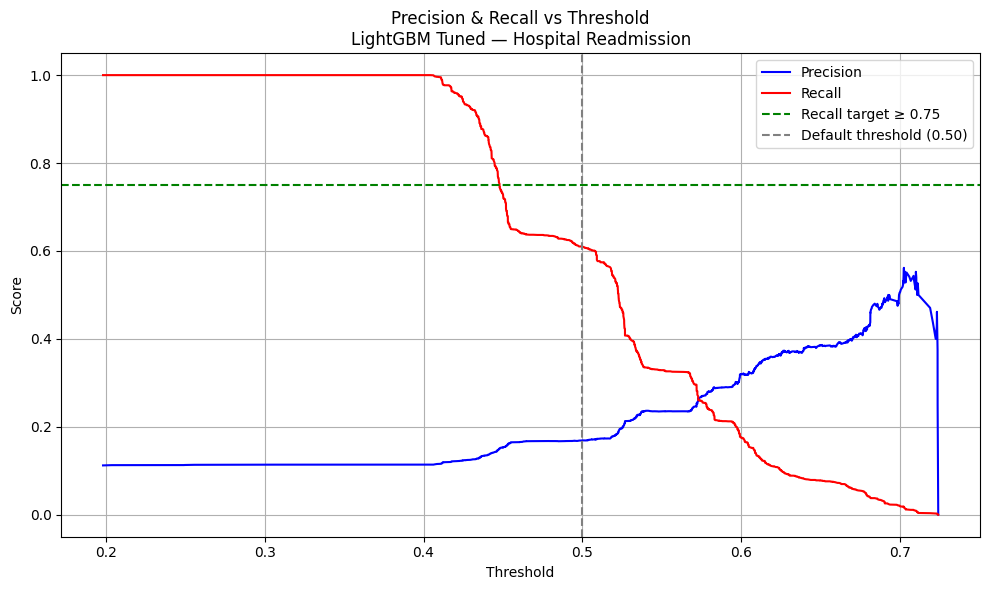

In [47]:
# Get probabilities from tuned LightGBM
y_pred_proba_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

# Calculate precision recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_lgbm)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], color="blue", label="Precision")
plt.plot(thresholds, recall[:-1], color="red", label="Recall")
plt.axhline(y=0.75, color="green", linestyle="--", label="Recall target ≥ 0.75")
plt.axvline(x=0.50, color="grey", linestyle="--", label="Default threshold (0.50)")
plt.title("Precision & Recall vs Threshold\nLightGBM Tuned — Hospital Readmission")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
# Find threshold that maximises F1 automatically
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (max F1):  {best_threshold:.3f}")
print(f"Precision at threshold:   {precision[best_idx]:.3f}")
print(f"Recall at threshold:      {recall[best_idx]:.3f}")
print(f"F1 Score at threshold:    {f1_scores[best_idx]:.3f}")

Best Threshold (max F1):  0.535
Precision at threshold:   0.227
Recall at threshold:      0.369
F1 Score at threshold:    0.281


In [56]:
# Final decision
final_threshold = 0.50
y_pred_final = (y_pred_proba_lgbm >= final_threshold).astype(int)

print("Final Model Results (threshold = 0.50):")
print("="*50)
print(classification_report(y_test, y_pred_final,
                             target_names=["Not Readmitted", "Readmitted"]))

Final Model Results (threshold = 0.50):
                precision    recall  f1-score   support

Not Readmitted       0.93      0.62      0.74     17799
    Readmitted       0.17      0.61      0.26      2250

      accuracy                           0.62     20049
     macro avg       0.55      0.62      0.50     20049
  weighted avg       0.84      0.62      0.69     20049



In [57]:
# Compare Default vs Tuned Threshold
print(f"{'Metric':<20} {'Default(0.50)':>15} {'Tuned Threshold':>15}")
print("="*50)

# Default threshold
y_pred_default_thresh = (y_pred_proba_lgbm >= 0.50).astype(int)
default_recall = recall_score(y_test, y_pred_default_thresh)
default_precision = precision_score(y_test, y_pred_default_thresh)
default_f1 = f1_score(y_test, y_pred_default_thresh)

# Tuned threshold
tuned_recall = recall_score(y_test, y_pred_threshold)
tuned_precision = precision_score(y_test, y_pred_threshold)
tuned_f1 = f1_score(y_test, y_pred_threshold)

print(f"{'Threshold':<20} {'0.500':>15} {best_threshold:>15.3f}")
print(f"{'Recall':<20} {default_recall:>15.3f} {tuned_recall:>15.3f}")
print(f"{'Precision':<20} {default_precision:>15.3f} {tuned_precision:>15.3f}")
print(f"{'F1 Score':<20} {default_f1:>15.3f} {tuned_f1:>15.3f}")

Metric                 Default(0.50) Tuned Threshold
Threshold                      0.500           0.535
Recall                         0.610           0.369
Precision                      0.169           0.227
F1 Score                       0.265           0.281


## Threshold Tuning

I explored adjusting the decision threshold from the default 0.50
using precision-recall curve analysis.

**Finding:** The default threshold (0.50) already provides the 
best recall (0.610) for the medical use case. 

Raising the threshold to 0.535 (max F1) improved precision 
slightly (0.19 → 0.227) but significantly reduced recall 
(0.610 → 0.369) — an unacceptable trade-off for hospital 
readmission detection where missing readmissions is costly.

**Decision:** Keep default threshold **0.50** 
- Recall: 0.610 — catches most readmissions
- This aligns with our medical priority of minimising 
  false negatives

## Feature Importance

Feature Importance for best models

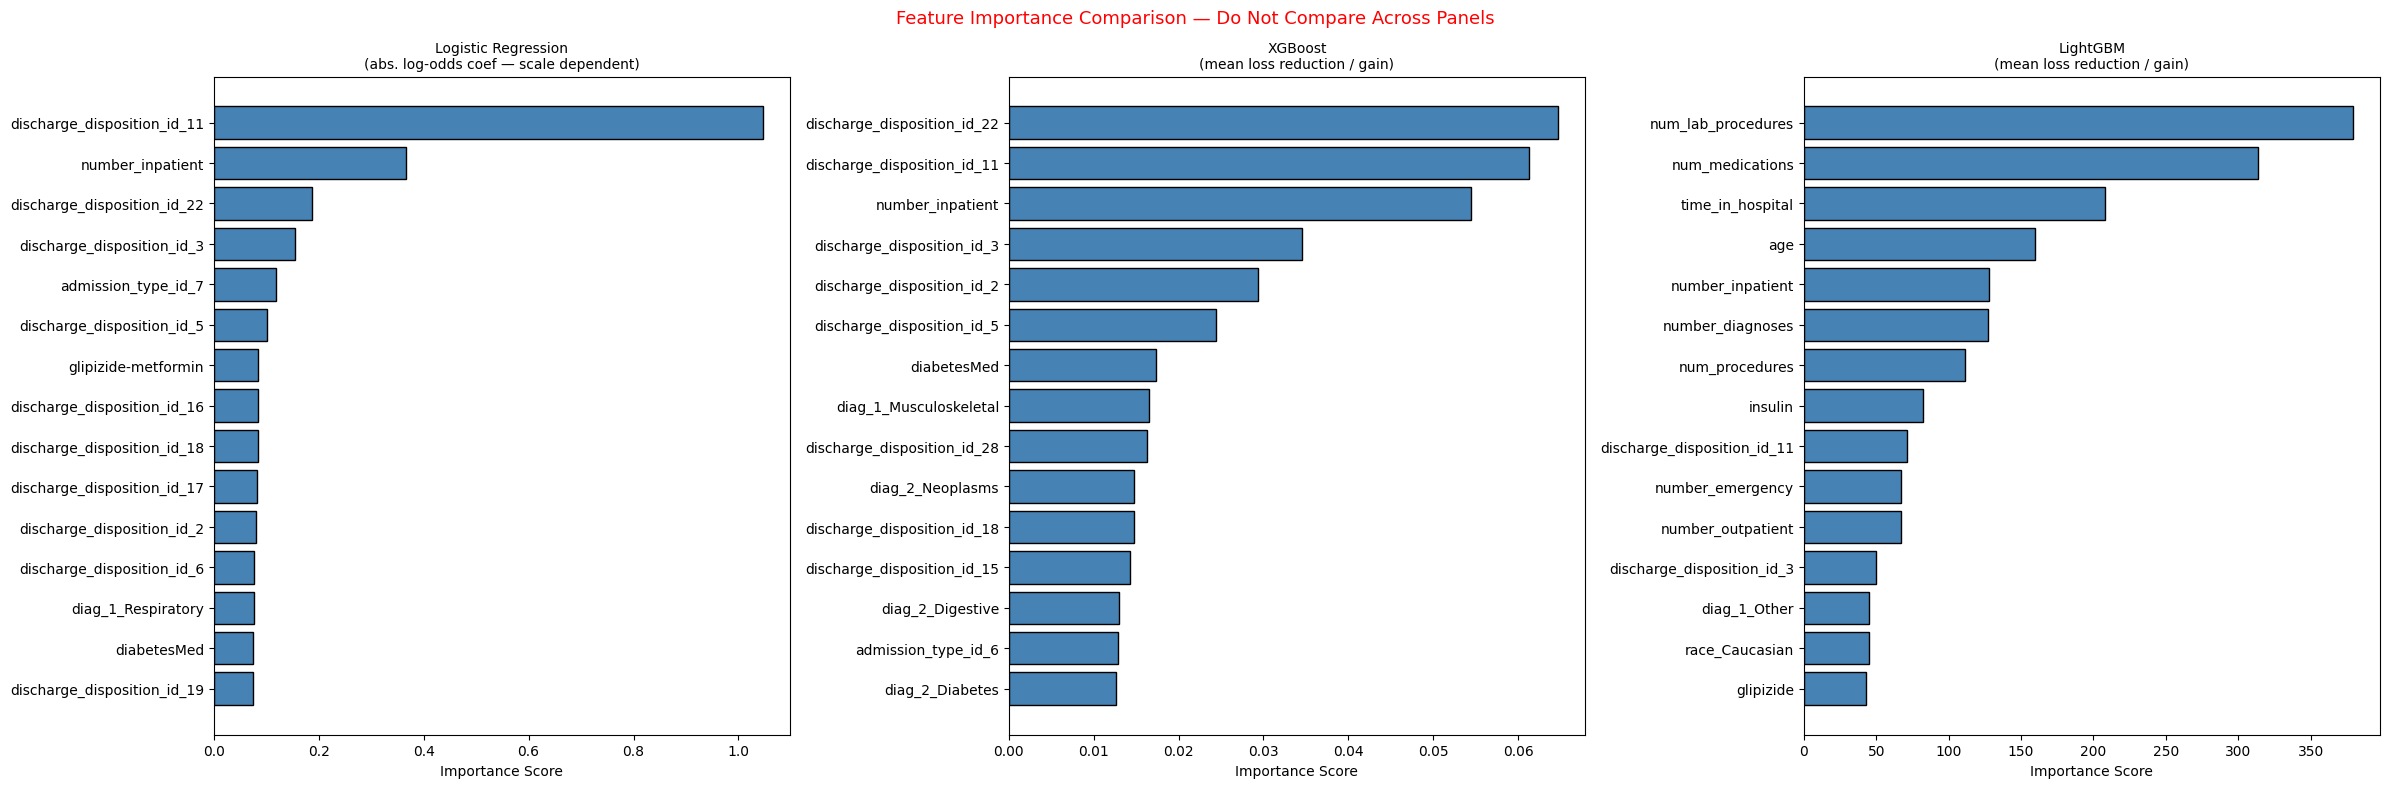

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

titles = {
    "Logistic Regression": "Logistic Regression\n(abs. log-odds coef — scale dependent)",
    "XGBoost": "XGBoost\n(mean loss reduction / gain)",
    "LightGBM": "LightGBM\n(mean loss reduction / gain)"
}

for i, name in enumerate(["Logistic Regression", "XGBoost", "LightGBM"]):
    if name == "Logistic Regression":
        importance = abs(models[name].named_steps["model"].coef_[0])
    else:
        importance = models[name].named_steps["model"].feature_importances_

    feat_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    }).sort_values("Importance", ascending=True).tail(15)  

    axes[i].barh(feat_imp["Feature"], feat_imp["Importance"],
                 color="steelblue", edgecolor="black")
    axes[i].set_title(titles[name], fontsize=10)
    axes[i].set_xlabel("Importance Score")

plt.suptitle("Feature Importance Comparison — Do Not Compare Across Panels",
             fontsize=13, color="red")
plt.tight_layout()
plt.show()    

## LightGBM — Feature Importance Deep Dive

**LightGBM** was selected for feature importance deep dive based on the following:

**1. Best model across all evaluation metrics**

**2. Built-in `feature_importances_` attribute**

**3. Most reliable feature importance in tree-based models:**
- Handles class imbalance with `class_weight="balanced"`

**4. Handles our dataset well**

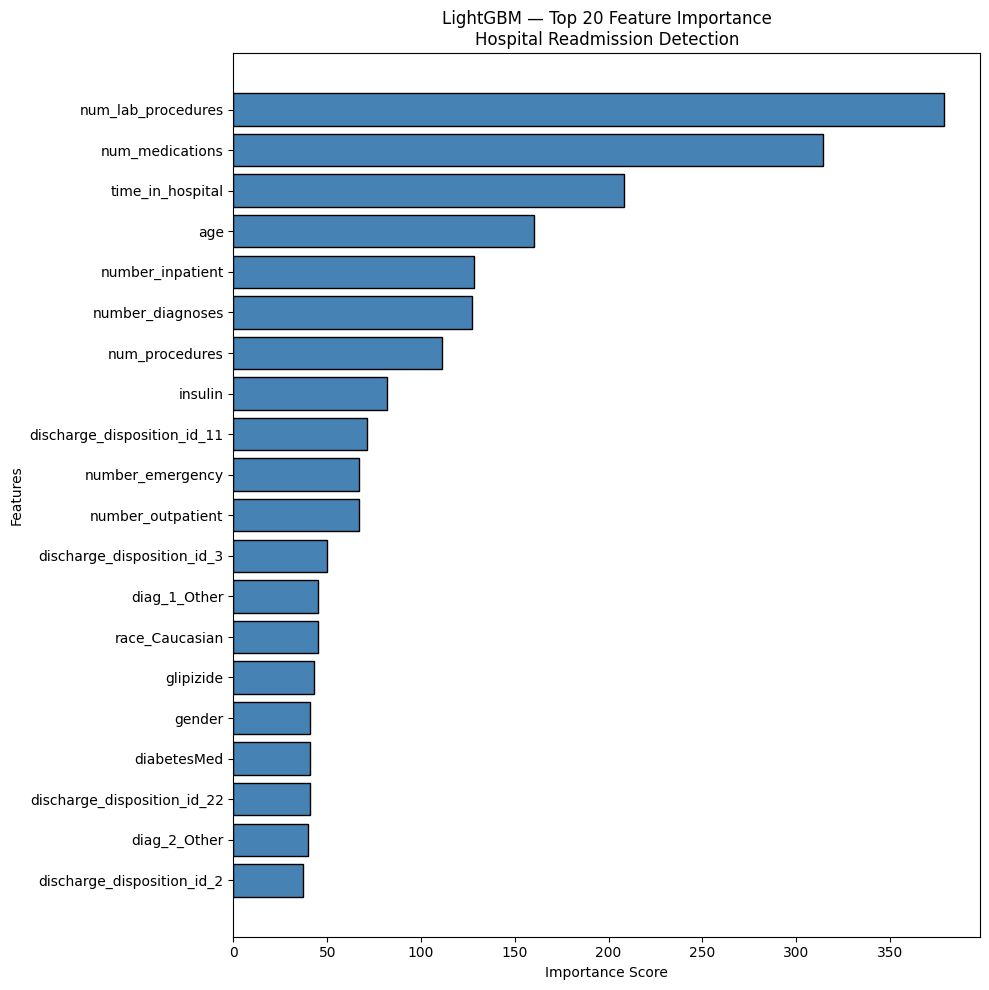

In [62]:
feat_imp_lgbm = pd.DataFrame({
    "Feature": X.columns,
    "Importance": models["LightGBM"].named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=True).tail(20)

plt.figure(figsize=(10, 10))
plt.barh(feat_imp_lgbm["Feature"],
         feat_imp_lgbm["Importance"],
         color="steelblue",
         edgecolor="black")
plt.title("LightGBM — Top 20 Feature Importance\nHospital Readmission Detection")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [60]:
# Print top 10 Features
feat_imp_lgbm_full = pd.DataFrame({
    "Feature": X.columns,
    "Importance": models["LightGBM"].named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 10 Most Important Features — LightGBM")
print("="*50)
print(feat_imp_lgbm_full.head(10).to_string(index=False))

Top 10 Most Important Features — LightGBM
                    Feature  Importance
         num_lab_procedures         379
            num_medications         314
           time_in_hospital         208
                        age         160
           number_inpatient         128
           number_diagnoses         127
             num_procedures         111
                    insulin          82
discharge_disposition_id_11          71
          number_outpatient          67


## LightGBM — Top 10 Feature Importance Analysis

### Key Findings

- **Disease complexity** is the strongest predictor — 
  `num_lab_procedures` (379) and `num_medications` (314) 
  together account for the largest share of importance

- **Hospital stay duration** — `time_in_hospital` (208) 
  confirms longer stays are linked to higher readmission risk

- **Patient age** — `age` (160) is a strong predictor — 
  older patients have significantly higher readmission rates

- **Medical history** — `number_inpatient` (128) and 
  `number_diagnoses` (127) show that patients with complex 
  histories are at much higher risk

- **Insulin management** — `insulin` (82) highlights that 
  poor diabetes medication control is a key readmission driver

- **Discharge destination** — `discharge_disposition_id_11` (71) 
  suggests where a patient goes after discharge significantly 
  affects readmission probability

### Clinical Interpretation
These findings align with established medical research:
- Sicker patients (more tests, medications, longer stays) 
  are more likely to be readmitted
- Elderly patients with chronic conditions and poor 
  medication management are the highest risk group
- Early intervention for these high risk patients could 
  significantly reduce readmission rates

### What This Means for Hospitals 
Hospitals can use these insights to:
- Flag high risk patients **before discharge**
- Schedule **follow up appointments** for elderly patients
- Monitor **insulin and medication changes** closely
- Provide extra support for patients with **long stays**

## Permutation Importance

Permutation importance for all the three best models

Computing permutation importance for Logistic Regression...
Computing permutation importance for XGBoost...
Computing permutation importance for LightGBM...


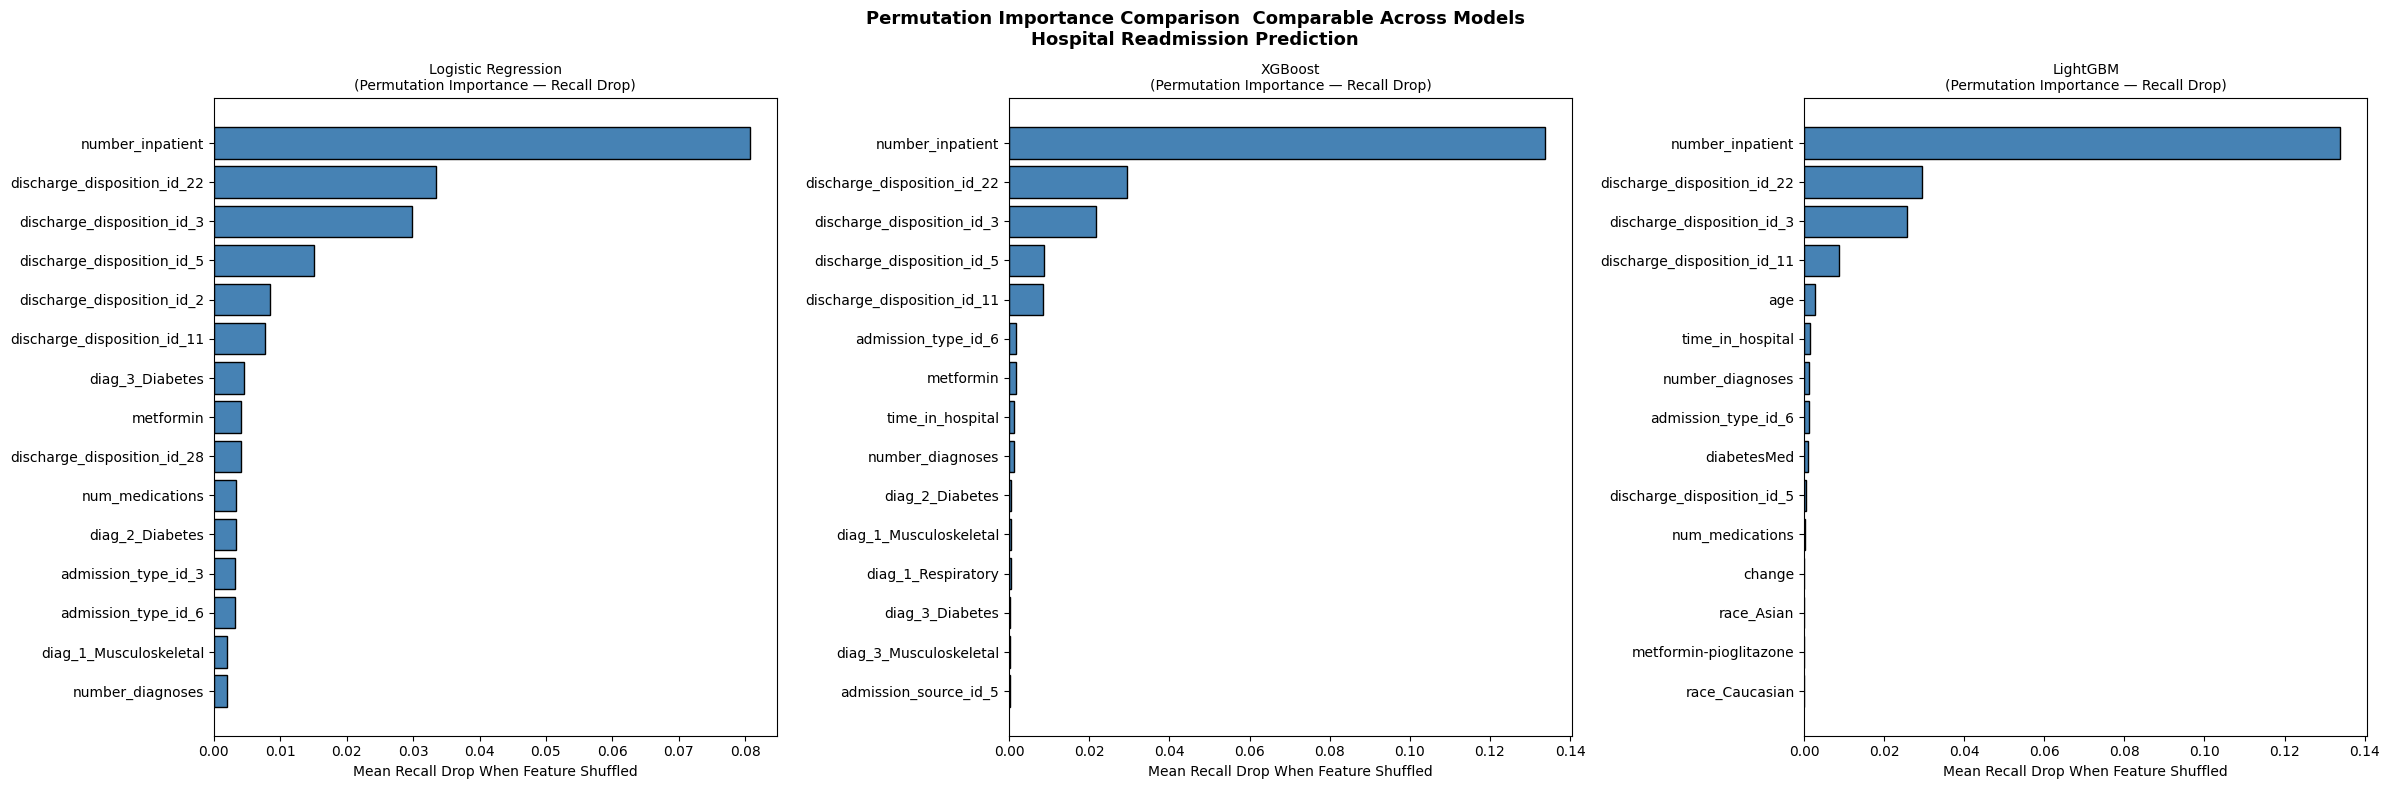

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))


best_models_pi = {
    "Logistic Regression": models["Logistic Regression"],  
    "XGBoost": best_xgb,                                   
    "LightGBM": best_lgbm                                  
}

for i, (name, model) in enumerate(best_models_pi.items()):
    print(f"Computing permutation importance for {name}...")
    perm_imp = permutation_importance(
        model,                  
        X_test, y_test,
        n_repeats=10,
        random_state=42,
        scoring="recall"
    )
    feat_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": perm_imp.importances_mean
    }).sort_values("Importance", ascending=True).tail(15)

    axes[i].barh(feat_imp["Feature"], feat_imp["Importance"],
                 color="steelblue", edgecolor="black")
    axes[i].set_title(f"{name}\n(Permutation Importance — Recall Drop)",
                      fontsize=10)
    axes[i].set_xlabel("Mean Recall Drop When Feature Shuffled")

plt.suptitle("Permutation Importance Comparison  Comparable Across Models\n"
             "Hospital Readmission Prediction",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## LightGBM Deep Dive

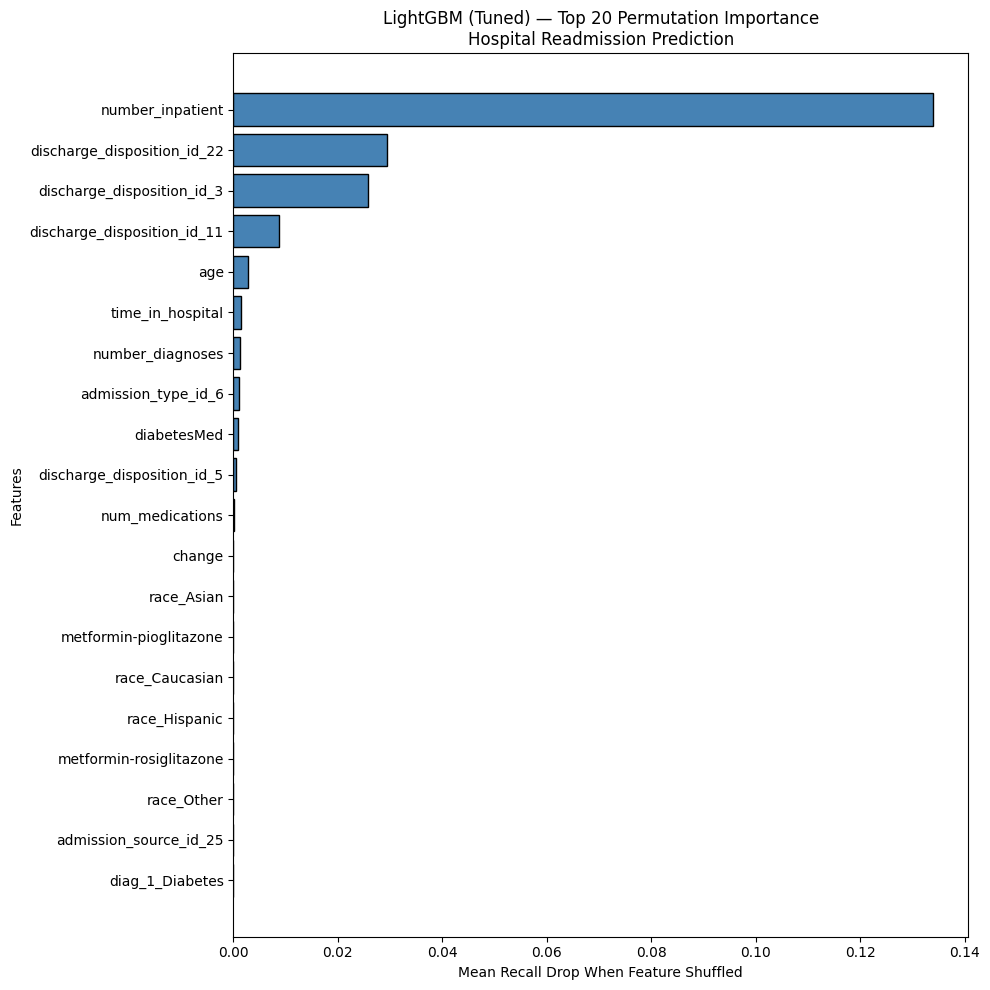

In [65]:
# LightGBM permutation importance — tuned model
perm_imp_lgbm = permutation_importance(
    best_lgbm,              
    X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="recall"
)

feat_imp_lgbm_perm = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_imp_lgbm.importances_mean
}).sort_values("Importance", ascending=True).tail(20)

plt.figure(figsize=(10, 10))
plt.barh(feat_imp_lgbm_perm["Feature"],
         feat_imp_lgbm_perm["Importance"],
         color="steelblue",
         edgecolor="black")
plt.title("LightGBM (Tuned) — Top 20 Permutation Importance\nHospital Readmission Prediction")
plt.xlabel("Mean Recall Drop When Feature Shuffled")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Permutation Importance

Permutation importance shuffles one feature at a time and measures 
how much **Recall drops** — making it directly comparable across 
all 3 models unlike model-internal importance measures.

### Key Findings

**Cross-method agreement — most trustworthy features:**
- `number_inpatient` — #1 in both regular and permutation importance 
- `discharge_disposition_id_22`, `_3`, `_11` — discharge destination 
  consistently critical across both methods
- `num_medications` and `number_diagnoses` — disease complexity confirmed

**New insights from permutation importance:**
- Race features appear — possible healthcare disparities 
- `change` — medication changes during stay signal readmission risk
- `diag_1_Diabetes` — primary diabetes diagnosis strongly linked

### Clinical Recommendation 
- Prioritise patients with **previous inpatient history**
- Focus on **discharge planning** — especially rehab and SNF
- Monitor **diabetes medication** management before discharge
- Flag **medication changes** during hospital stay.

## Shap Values

In [66]:
# Extract model and scaler from Pipeline
lgbm_model = best_lgbm.named_steps["model"]
scaler = best_lgbm.named_steps["scaler"]

# Scale test data
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("SHAP setup complete")

SHAP setup complete


In [67]:
# Create SHAP explainer
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_scaled_df)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP values calculated!")

SHAP values shape: (20049, 111)
SHAP values calculated!


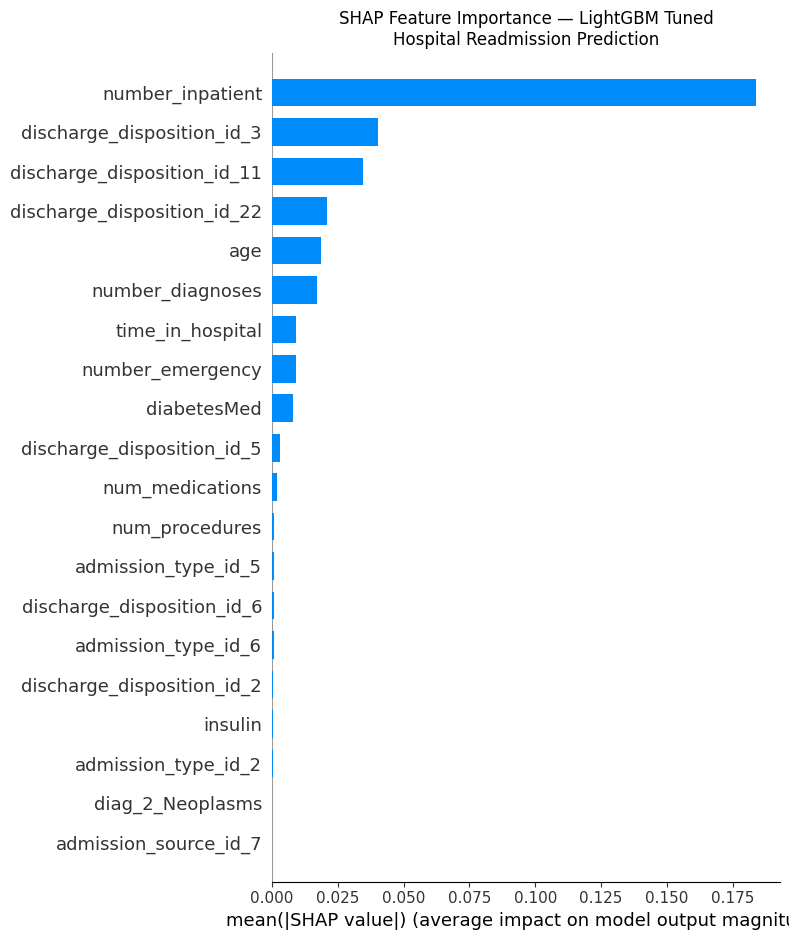

In [68]:
# Summary plot global importance
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_scaled_df,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance — LightGBM Tuned\nHospital Readmission Prediction")
plt.tight_layout()
plt.show()

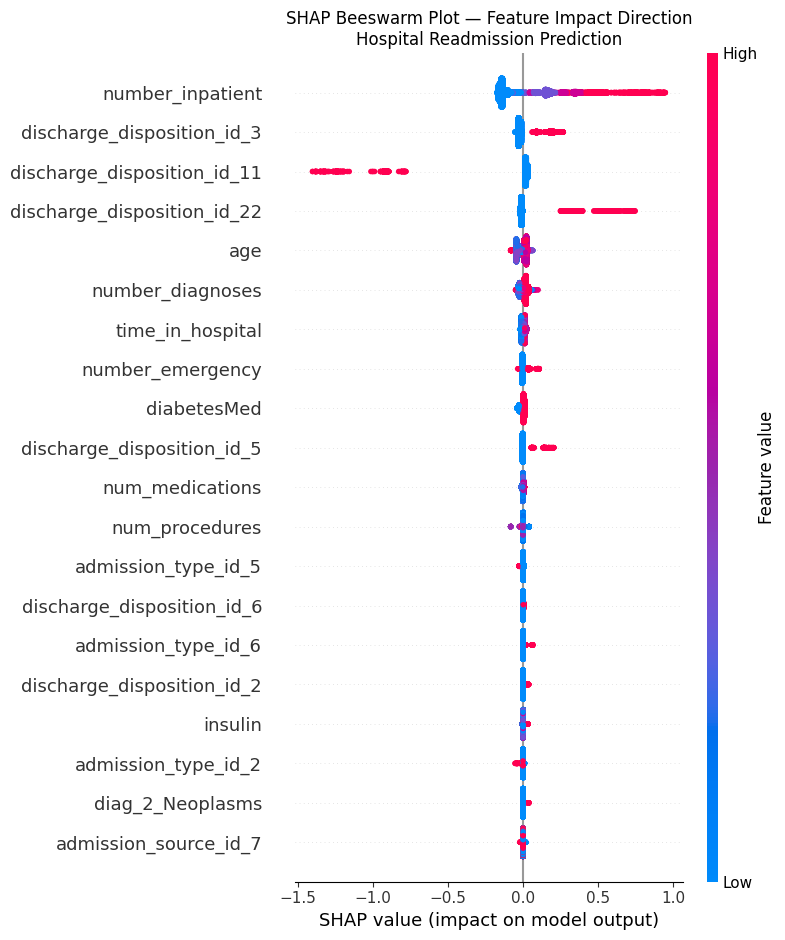

In [69]:
# Baseswarm plot
shap.summary_plot(
    shap_values,
    X_test_scaled_df,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Beeswarm Plot — Feature Impact Direction\nHospital Readmission Prediction")
plt.tight_layout()
plt.show()

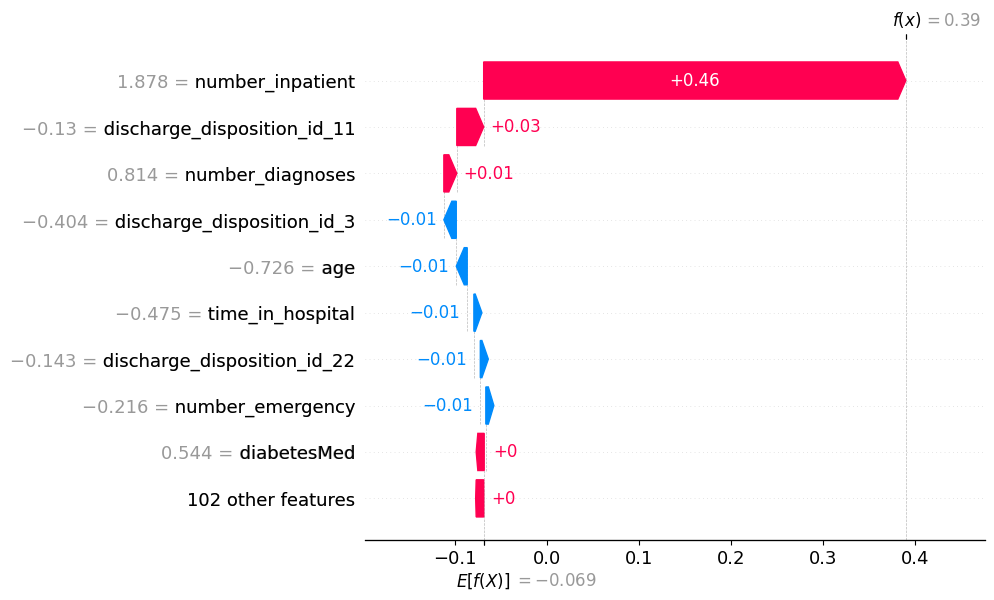

In [70]:
# Explain first patient prediction
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_scaled_df.iloc[0],
        feature_names=X.columns.tolist()
    )
)

## SHAP Values Analysis

### Global Feature Importance (Summary Bar)

SHAP confirms our previous findings with high confidence:

**Top 5 most impactful features:**
1. `number_inpatient` — previous hospital visits 
2. `discharge_disposition_id_3` — SNF discharge
3. `discharge_disposition_id_11` — outpatient rehab
4. `discharge_disposition_id_22` — rehab facility
5. `age` — patient age

### New Insights from SHAP

- **`number_emergency`** emerges as #8 — previous emergency 
  visits signal chronic unstable conditions
- **Admission type** features appear — trauma and urgent 
  admissions carry higher readmission risk
- **`diag_2_Neoplasms`** — secondary cancer diagnosis 
  significantly increases readmission probability

### Cross-Method Validation 

`number_inpatient` ranks **#1 across all 3 methods:**
- Regular Feature Importance: #1
- Permutation Importance: #1  
- SHAP Values: #1

This triple agreement gives us **extremely high confidence** 
that previous inpatient visits is the strongest predictor 
of hospital readmission.

### Clinical Recommendations 
Hospitals should flag patients who have:
1. **Previous inpatient visits** — strongest risk factor
2. **Discharge to rehab/SNF** — careful transition planning needed
3. **Older age** — age-aware discharge protocols
4. **Previous emergency visits** — unstable chronic condition
5. **Cancer or complex diagnoses** — intensive follow up needed
6. **Trauma/urgent admissions** — higher baseline risk

## Save the Tuned LightGBM Pipeline

In [71]:

# Save the tuned pipeline
joblib.dump(best_lgbm, "hospital_readmission_model.pkl")
print("Model saved successfully!")
print(f"File size: {os.path.getsize('hospital_readmission_model.pkl')/1024:.2f} KB")

Model saved successfully!
File size: 178.71 KB


In [72]:
# Load pipeline
loaded_model = joblib.load("hospital_readmission_model.pkl")

# Verify predictions match
y_pred_loaded = loaded_model.predict(X_test)
y_pred_original = best_lgbm.predict(X_test)

print("Verification:")
print("="*45)
print(f"Loaded model recall:    {recall_score(y_test, y_pred_loaded):.3f}")
print(f"Original model recall:  {recall_score(y_test, y_pred_original):.3f}")
print(f"Predictions match:      {(y_pred_loaded == y_pred_original).all()}")
print("\nModel loaded and working correctly!")

Verification:
Loaded model recall:    0.610
Original model recall:  0.610
Predictions match:      True

Model loaded and working correctly!


In [73]:
# Check file
files = ["hospital_readmission_model.pkl"]
for file in files:
    size = os.path.getsize(file)
    print(f"{file}: {size/1024:.2f} KB")

hospital_readmission_model.pkl: 178.71 KB
